<a href="https://colab.research.google.com/github/Patricio2088/semana-4/blob/main/Clasificacion_imagenes_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Importar las librerías necesarias
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

In [2]:
# Cargar el conjunto de datos MNIST
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Normalizar las imágenes a un rango entre 0 y 1
train_images = train_images / 255.0
test_images = test_images / 255.0

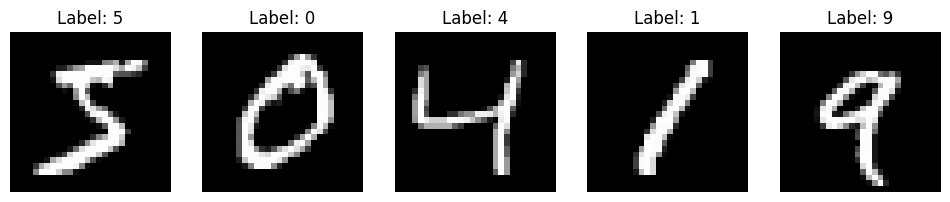

In [4]:
# Visualizar algunas imágenes del conjunto de entrenamiento
fig, axes = plt.subplots(1, 5, figsize=(12, 6))
for i in range(5):
    axes[i].imshow(train_images[i], cmap="gray")
    axes[i].set_title(f"Label: {train_labels[i]}")
    axes[i].axis('off')
plt.show()

In [5]:
# Definir la red neuronal
model = models.Sequential([
    # Aplanar la imagen de 28x28 a un vector de 784 elementos
    layers.Flatten(input_shape=(28, 28)),
    # Capa densa con 128 neuronas y función de activación ReLU
    layers.Dense(128, activation='relu'),
    # Capa de salida con 10 neuronas (una para cada dígito 0-9)
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [6]:
# Compilar el modelo
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [7]:
# Entrenamiento del modelo
model.fit(train_images, train_labels, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8753 - loss: 0.4343
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9649 - loss: 0.1218
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9764 - loss: 0.0791
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9828 - loss: 0.0571
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9864 - loss: 0.0442


In [8]:
# Evaluación del modelo
test_loss, test_acc = model.evaluate(test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9723 - loss: 0.0844


In [9]:
# Mostrar el resultado de la precisión en el conjunto de prueba
print(f"Test accuracy: {test_acc:.4f}")

Test accuracy: 0.9755


In [10]:
# Hacer predicciones con el modelo entrenado
predictions = model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


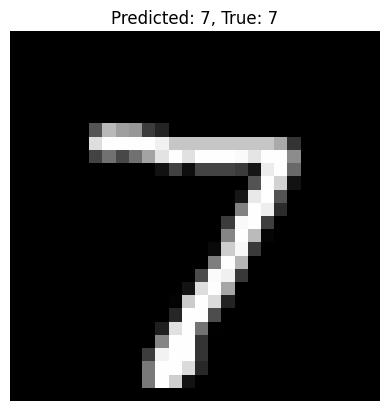

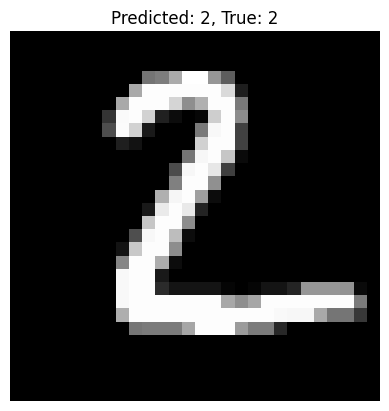

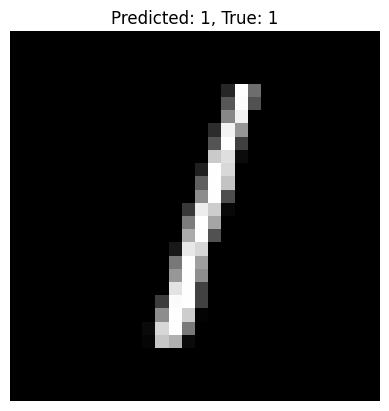

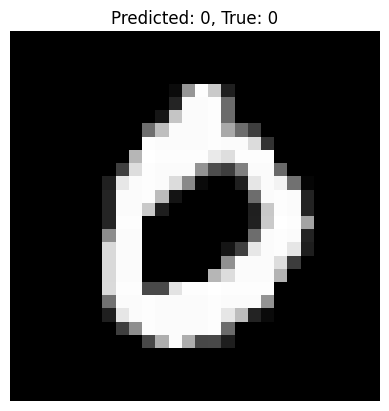

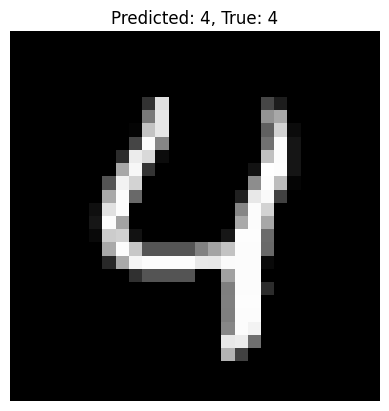

In [11]:
# Mostrar algunas predicciones
for i in range(5):
    plt.imshow(test_images[i], cmap="gray")
    plt.title(f"Predicted: {predictions[i].argmax()}, True: {test_labels[i]}")
    plt.axis('off')
    plt.show()